# Lab 4: Algorithms, Noise & Mini-Project

**Qiskit 101 — Session 4**  
**Duration:** 3 Hours  
**Main Outcome:** Implement a complete Qiskit application

---

## 🎯 Learning Objectives

By the end of this lab, you will be able to:

1. **Implement a simple quantum algorithm** using Qiskit and explain the role of each circuit component.

2. **Connect quantum circuits to computational problems** by identifying inputs, quantum operations, measurements, and outputs.

3. **Execute quantum algorithms using simulation and quantum hardware workflows** introduced in the previous labs.

4. **Investigate the effect of noise** on quantum computation by comparing ideal and noisy execution results.

5. **Interpret measurement results probabilistically** and distinguish expected algorithmic behaviour from hardware or noise-induced deviations.

6. **Apply the complete Qiskit workflow**:
   
   **Problem → Circuit → Transpilation → Execution → Measurement → Analysis**

7. **Integrate the concepts from Labs 1–3** to design and implement a small end-to-end quantum computing application.

---

## 🧩 Lab 4 Roadmap

In this lab, we will move through three stages:

**Part A — Quantum Algorithm**  
Build and understand a small quantum algorithm.

**Part B — Noise & Realistic Execution**  
Study how noise affects quantum computation and compare ideal and noisy results.

**Part C — Mini-Project**  
Apply the complete Qiskit workflow to solve a small computational problem.

---

> **Key idea:** In the previous labs, we learned how to build circuits, create entanglement, and execute circuits on quantum hardware.  
> In this final lab, we bring these skills together to build a **complete quantum application**.

In [ ]:
!pip install  "qiskit[visualization]" pylatexenc qiskit-aer qiskit-ibm-runtime

# Part A — Your First Quantum Algorithm: Deutsch–Jozsa

So far, we have learned how to:

- create quantum circuits,
- manipulate single and multiple qubits,
- generate entanglement,
- measure quantum states,
- transpile circuits, and
- prepare circuits for execution on real quantum hardware.

We will now combine these ideas to implement our first **quantum algorithm**.

## The Deutsch–Jozsa Problem

Suppose we are given a function

\[
f:\{0,1\}^n \rightarrow \{0,1\}
\]

with the promise that the function is either:

- **Constant:** it produces the same output for every possible input, or
- **Balanced:** it produces `0` for exactly half of the inputs and `1` for the other half.

Our task is to determine whether the function is **constant or balanced**.

### Example for two input bits

A constant function might behave as:

| Input | Output |
|------|------|
| 00 | 0 |
| 01 | 0 |
| 10 | 0 |
| 11 | 0 |

A balanced function might behave as:

| Input | Output |
|------|------|
| 00 | 0 |
| 01 | 1 |
| 10 | 1 |
| 11 | 0 |

## Classical vs Quantum Approach

Classically, in the worst case, we may need to evaluate the function

\[
2^{n-1}+1
\]

times to determine with certainty whether it is constant or balanced.

The **Deutsch–Jozsa algorithm requires only one evaluation of the quantum oracle**.

> **Key Question:** How can a quantum circuit obtain information about many possible inputs using only one oracle call?

The answer involves three ideas that we have already encountered:

**Superposition + Phase + Interference**

## A2. Step 1 — Preparing the Quantum Registers

We will implement the Deutsch–Jozsa algorithm for a function with **2 input bits**.

The circuit therefore requires:

- **2 input qubits** — representing the input \(x\)
- **1 ancilla qubit** — used by the quantum oracle
- **2 classical bits** — used to measure the input qubits

We begin in the state

\[
|00\rangle|0\rangle
\]

where the first two qubits form the **input register** and the third qubit is the **ancilla**.

### Why do we need an ancilla?

The oracle implements the function through the transformation

\[
U_f|x\rangle|y\rangle
=
|x\rangle|y \oplus f(x)\rangle
\]

The input \(x\) is preserved, while the value of \(f(x)\) affects the ancilla qubit.

### Initial preparation

Before applying the oracle:

1. The input qubits remain in \(|0\rangle\).
2. Apply an **X gate** to the ancilla to prepare it in \(|1\rangle\).
3. Apply a **Hadamard gate to all three qubits**.

The input register then enters an equal superposition of all possible inputs:

\[
|00\rangle,\ |01\rangle,\ |10\rangle,\ |11\rangle
\]

This allows the oracle to act on the superposition rather than on only one classical input.

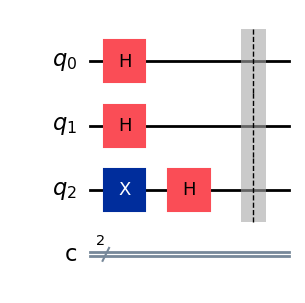

In [ ]:
from qiskit import QuantumCircuit

# 2 input qubits + 1 ancilla qubit
dj_circuit = QuantumCircuit(3, 2)

# Prepare the ancilla in |1>
dj_circuit.x(2)

# Apply Hadamard gates to all qubits
dj_circuit.h([0, 1, 2])

# Add a barrier for visual clarity
dj_circuit.barrier()

# Draw the circuit
dj_circuit.draw("mpl")

### 🔍 What Happened to the Quantum State?

Let us examine what the gates in the previous circuit have done.

#### Input Qubits

Both input qubits started in the state

\[
|0\rangle.
\]

Applying a Hadamard gate transforms each of them into

\[
H|0\rangle = |+\rangle
=
\frac{|0\rangle+|1\rangle}{\sqrt{2}}.
\]

Therefore, the two input qubits together are in the state

\[
|+\rangle|+\rangle
=
\frac{1}{2}
(|00\rangle+|01\rangle+|10\rangle+|11\rangle).
\]

The input register is therefore in an **equal superposition of all four possible inputs**.

---

#### Ancilla Qubit

The ancilla starts in

\[
|0\rangle.
\]

First, the X gate changes it to

\[
X|0\rangle = |1\rangle.
\]

Then the Hadamard gate transforms it into

\[
H|1\rangle = |-\rangle
=
\frac{|0\rangle-|1\rangle}{\sqrt{2}}.
\]

Thus, before entering the oracle, the complete system is

\[
\frac{1}{2}
(|00\rangle+|01\rangle+|10\rangle+|11\rangle)
\otimes |-\rangle.
\]

---

### 💡 Why is this preparation important?

The **input register** contains all possible inputs in superposition, while the **ancilla is prepared in the \(|-\rangle\) state**.

This special preparation allows the oracle to encode information about

\[
f(x)
\]

as a **phase** on the input states.

This phenomenon is called **phase kickback** and is one of the key ideas behind the Deutsch–Jozsa algorithm.

> **Think:** The oracle will not simply calculate and display \(f(x)\).  
> Instead, it will encode information about \(f(x)\) into the **phase of the quantum state**, which we will later reveal using interference.

A3: Understanding the Quantum Oracle and Phase Kickback

## A3. Understanding the Quantum Oracle and Phase Kickback

The central component of the Deutsch–Jozsa algorithm is the **quantum oracle**.

The oracle represents the function

\[
f:\{0,1\}^n \rightarrow \{0,1\}.
\]

In a quantum circuit, the oracle is implemented as a **unitary operation** \(U_f\):

\[
U_f|x\rangle|y\rangle
=
|x\rangle|y \oplus f(x)\rangle
\]

where:

- \(x\) represents the input register,
- \(y\) represents the ancilla qubit,
- \(f(x)\) is the value of the function, and
- \(\oplus\) represents XOR (addition modulo 2).

---

### What happens when the ancilla is \(|-\rangle\)?

Recall that we prepared the ancilla in

\[
|-\rangle
=
\frac{|0\rangle-|1\rangle}{\sqrt{2}}.
\]

Now consider the two possible values of \(f(x)\).

#### Case 1: \(f(x)=0\)

The oracle does not flip the ancilla:

\[
U_f|x\rangle|-\rangle
=
|x\rangle|-\rangle.
\]

Therefore, the input state receives no change in phase.

#### Case 2: \(f(x)=1\)

The oracle applies an X operation to the ancilla.

But

\[
X|-\rangle=-|-\rangle.
\]

Therefore,

\[
U_f|x\rangle|-\rangle
=
-|x\rangle|-\rangle.
\]

The ancilla effectively returns to the same \(|-\rangle\) state, but the corresponding input state acquires a **minus sign**.

---

### Phase Kickback

Combining both cases, we can write

\[
U_f|x\rangle|-\rangle
=
(-1)^{f(x)}|x\rangle|-\rangle.
\]

Therefore:

\[
f(x)=0
\quad\Rightarrow\quad
(+1)|x\rangle
\]

and

\[
f(x)=1
\quad\Rightarrow\quad
(-1)|x\rangle.
\]

The value of the function has been encoded into the **phase of the input state**.

This phenomenon is called **phase kickback**.

---

### Example

Suppose a balanced function for two input qubits is

\[
f(x_0,x_1)=x_0.
\]

Then:

| Input | \(f(x)\) | Phase after Oracle |
|------|------:|------|
| 00 | 0 | \(+|00\rangle\) |
| 01 | 1 | \(-|01\rangle\) |
| 10 | 0 | \(+|10\rangle\) |
| 11 | 1 | \(-|11\rangle\) |

Thus, the superposition

\[
\frac{1}{2}
(|00\rangle+|01\rangle+|10\rangle+|11\rangle)
\]

becomes

\[
\frac{1}{2}
(|00\rangle-|01\rangle+|10\rangle-|11\rangle).
\]

Notice that the oracle has not measured the qubits.

Instead, information about \(f(x)\) has been encoded in the **relative phases** of the computational basis states.

---

> **Key Idea:**  
> **Superposition** allows the oracle to act on all possible inputs.  
> **Phase kickback** encodes \(f(x)\) into their relative phases.  
> **Interference**, introduced in the next step, allows us to extract useful information from these phases.

### A3.1 Implementing a Balanced Oracle

Let us construct a simple **balanced function** using the first input qubit.

We define

\[
f(x_0,x_1)=x_0.
\]

Therefore, the function produces:

| \(x_0\) | \(x_1\) | \(f(x_0,x_1)\) |
|---|---|---|
| 0 | 0 | 0 |
| 0 | 1 | 0 |
| 1 | 0 | 1 |
| 1 | 1 | 1 |

The function produces `0` for half of the possible inputs and `1` for the
other half. Therefore, it is a **balanced function**.

---

### Implementing the Oracle

We can implement this function using a **CNOT (CX) gate**:

- **Control:** input qubit \(q_0\)
- **Target:** ancilla qubit \(q_2\)

The CNOT flips the ancilla whenever

\[
x_0=1.
\]

Therefore, it implements

\[
|x\rangle|y\rangle
\longrightarrow
|x\rangle|y\oplus x_0\rangle.
\]

Since

\[
f(x_0,x_1)=x_0,
\]

this is exactly the required oracle transformation

\[
U_f|x\rangle|y\rangle
=
|x\rangle|y\oplus f(x)\rangle.
\]

Because the ancilla has already been prepared in the \(|-\rangle\) state,
the CNOT causes the states for which \(f(x)=1\) to acquire a negative phase.

> **Important:** We do not measure the ancilla to obtain \(f(x)\).
> The oracle encodes information about the function into the **relative
> phases of the input states**.

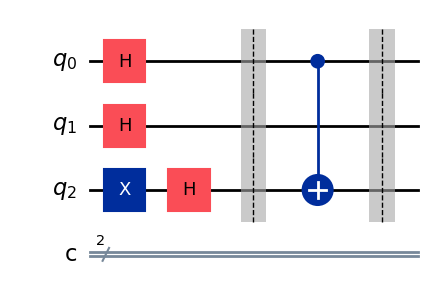

In [ ]:
# Balanced oracle: f(x0, x1) = x0
# q0 = control, q2 = ancilla

dj_circuit.cx(0, 2)

# Separate the oracle from the next stage
dj_circuit.barrier()

# Display the circuit
dj_circuit.draw("mpl")

### 🔍 What Did the Oracle Do?

Before the oracle, the input register is in an equal superposition:

\[
\frac{1}{2}
(|00\rangle+|01\rangle+|10\rangle+|11\rangle).
\]

The oracle implements the balanced function

\[
f(x_0,x_1)=x_0.
\]

Whenever \(x_0=1\), the oracle acts on the ancilla.

Because the ancilla is in the state

\[
|-\rangle,
\]

and

\[
X|-\rangle=-|-\rangle,
\]

the action of the oracle is transferred back to the corresponding input
state as a **negative phase**.

Thus, the oracle has encoded information about the function into the
relative phases of the superposition.

This is **phase kickback**.

However, there is an important problem:

### Can we measure this phase directly?

No.

A measurement in the computational basis detects probabilities, not the
relative phase signs directly.

We therefore need another operation that converts these phase differences
into measurable differences in probability.

That operation is the **Hadamard transform**.

> **Next step:** We will use quantum interference to convert the hidden
> phase information into a measurement result that tells us whether the
> function is constant or balanced.

### 🔍 What Did the Oracle Do?

Before the oracle, the input register is in an equal superposition:

\[
\frac{1}{2}
(|00\rangle+|01\rangle+|10\rangle+|11\rangle).
\]

The oracle implements the balanced function

\[
f(x_0,x_1)=x_0.
\]

Whenever \(x_0=1\), the oracle acts on the ancilla.

Because the ancilla is in the state

\[
|-\rangle,
\]

and

\[
X|-\rangle=-|-\rangle,
\]

the action of the oracle is transferred back to the corresponding input
state as a **negative phase**.

Thus, the oracle has encoded information about the function into the
relative phases of the superposition.

This is **phase kickback**.

However, there is an important problem:

### Can we measure this phase directly?

No.

A measurement in the computational basis detects probabilities, not the
relative phase signs directly.

We therefore need another operation that converts these phase differences
into measurable differences in probability.

That operation is the **Hadamard transform**.

> **Next step:** We will use quantum interference to convert the hidden
> phase information into a measurement result that tells us whether the
> function is constant or balanced.

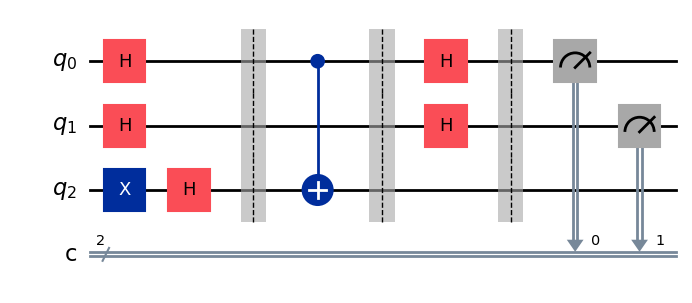

In [ ]:
# Apply Hadamard gates to the INPUT qubits only
dj_circuit.h([0, 1])

# Add a barrier before measurement
dj_circuit.barrier()

# Measure the two input qubits
dj_circuit.measure([0, 1], [0, 1])

# Display the completed Deutsch-Jozsa circuit
dj_circuit.draw("mpl")

### 🔍 Why Don't We Apply Hadamard to the Ancilla Again?

Notice that the final Hadamard gates are applied only to the **input qubits**.

The ancilla was necessary for implementing the oracle and producing
**phase kickback**, but we do not need to measure it.

After the oracle, the information required to distinguish a constant
function from a balanced function has been encoded into the relative
phases of the **input register**.

The final Hadamard gates cause these amplitudes to interfere.

Thus, the algorithm follows three fundamental quantum ideas:

\[
\boxed{\text{Superposition} \rightarrow
\text{Phase Kickback} \rightarrow
\text{Interference}}
\]

Measurement then converts the result of this interference into classical
information that we can interpret.

In [ ]:
from qiskit_aer import AerSimulator

# Create an ideal simulator
simulator = AerSimulator()

# Execute the circuit
job = simulator.run(dj_circuit, shots=1024)

# Get measurement counts
result = job.result()
counts = result.get_counts()

print("Measurement counts:", counts)

Measurement counts: {'01': 1024}


### 🔍 Interpreting the Result

Our measurement result is

\[
\texttt{01}: 1024
\]

This means that **all 1024 shots produced the same output `01`**.

Recall the Deutsch–Jozsa decision rule:

| Measurement | Interpretation |
|---|---|
| `00` | Constant function |
| Any non-zero bitstring | Balanced function |

Since

\[
\texttt{01} \neq \texttt{00},
\]

we conclude that

\[
\boxed{\text{The function is BALANCED}}
\]

This agrees with the oracle we constructed:

\[
f(x_0,x_1)=x_0.
\]

---

### Why Did We Obtain `01`?

Our balanced oracle used

\[
CX(q_0,q_2),
\]

where \(q_0\) is the input qubit controlling the ancilla.

After phase kickback and the final Hadamard transformation, the information
encoded by this oracle appears in \(q_0\).

Qiskit displays classical bitstrings in the order

\[
c_1c_0.
\]

Therefore,

\[
q_0=1,\qquad q_1=0
\]

is displayed as

\[
\texttt{01}.
\]

So `01` is exactly the result expected from this particular balanced oracle.

---

### Why Do All 1024 Shots Give the Same Answer?

The ideal simulator assumes **perfect quantum operations with no hardware
noise**.

For this Deutsch–Jozsa circuit, the interference is deterministic:

\[
P(01)=1.
\]

Therefore, repeating the experiment 1024 times produces

\[
\texttt{'01': 1024}.
\]

> **Important:** Quantum measurement is probabilistic in general, but a
> quantum algorithm can still produce a deterministic result when
> interference concentrates all probability on a particular outcome.

## A6. Testing a Constant Function

We have successfully tested a **balanced function** and obtained a non-zero
measurement result.

Now let us test the Deutsch–Jozsa algorithm using a **constant function**.

Consider the function

\[
f(x_0,x_1)=0
\]

for every possible input.

Its truth table is:

| \(x_0\) | \(x_1\) | \(f(x_0,x_1)\) |
|---|---|---|
| 0 | 0 | 0 |
| 0 | 1 | 0 |
| 1 | 0 | 0 |
| 1 | 1 | 0 |

The output is always `0`, so this is a **constant function**.

---

### What Should the Oracle Do?

The oracle transformation is

\[
U_f|x\rangle|y\rangle
=
|x\rangle|y\oplus f(x)\rangle.
\]

Since

\[
f(x)=0,
\]

we obtain

\[
y\oplus 0 = y.
\]

Therefore, the oracle does **nothing** to the qubits.

In circuit terminology, this oracle is simply the **identity operation**.

### Prediction

Before running the circuit, recall the Deutsch–Jozsa decision rule:

\[
\texttt{00} \Rightarrow \text{CONSTANT}
\]

\[
\text{non-zero bitstring} \Rightarrow \text{BALANCED}
\]

> **Before executing the circuit:** What measurement result do you expect
> for this constant oracle?

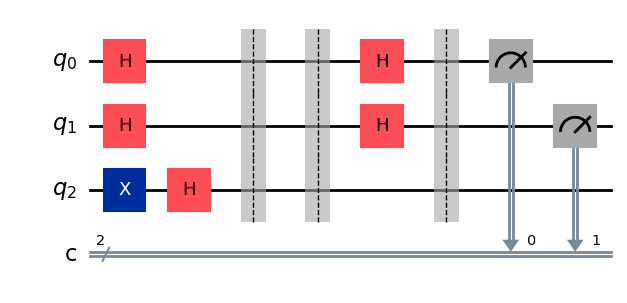

In [ ]:
from qiskit import QuantumCircuit

# Create a fresh Deutsch-Jozsa circuit
constant_circuit = QuantumCircuit(3, 2)

# --------------------------------
# Step 1: State preparation
# --------------------------------

# Prepare ancilla in |1>
constant_circuit.x(2)

# Create superposition
constant_circuit.h([0, 1, 2])

constant_circuit.barrier()

# --------------------------------
# Step 2: Constant oracle f(x) = 0
# --------------------------------

# No gate is required because f(x) = 0
# The oracle acts as the identity

constant_circuit.barrier()

# --------------------------------
# Step 3: Interference
# --------------------------------

constant_circuit.h([0, 1])

constant_circuit.barrier()

# --------------------------------
# Step 4: Measurement
# --------------------------------

constant_circuit.measure([0, 1], [0, 1])

# Display the complete circuit
constant_circuit.draw("mpl")

In [ ]:
# Execute on the same ideal simulator
job = simulator.run(constant_circuit, shots=1024)

# Get results
result = job.result()
constant_counts = result.get_counts()

print("Measurement counts:", constant_counts)

Measurement counts: {'00': 1024}


### 🔍 Comparing the Two Experiments

We have now executed the Deutsch–Jozsa algorithm with two different
oracles.

| Oracle | Function Type | Expected Measurement |
|---|---|---|
| \(f(x_0,x_1)=0\) | Constant | `00` |
| \(f(x_0,x_1)=x_0\) | Balanced | `01` |

The important observation is not the specific balanced bitstring.

The Deutsch–Jozsa decision rule is:

\[
\boxed{
\begin{aligned}
00 &\Rightarrow \text{CONSTANT}\\
\text{anything other than }00 &\Rightarrow \text{BALANCED}
\end{aligned}}
\]

Thus, a **single execution of the quantum oracle** is sufficient to
determine whether the promised function is constant or balanced.

---

### 🧠 What Made the Algorithm Work?

The Deutsch–Jozsa algorithm combines three fundamental quantum phenomena:

\[
\boxed{
\text{Superposition}
\rightarrow
\text{Phase Kickback}
\rightarrow
\text{Interference}
\rightarrow
\text{Measurement}
}
\]

**Superposition** allows the oracle to act on all possible input states.

**Phase kickback** encodes \(f(x)\) into their relative phases.

**Interference** combines these amplitudes so that the global property of
the function becomes observable.

**Measurement** converts the final quantum state into a classical result
that we can interpret.

> **Takeaway:** A quantum algorithm is not simply a classical algorithm
> executed on qubits. It deliberately manipulates amplitudes and phases so
> that interference makes the desired information observable.

## A7. Student Challenge — Build Your Own Balanced Oracle

So far, we have implemented:

- a constant function \(f(x_0,x_1)=0\), and
- a balanced function \(f(x_0,x_1)=x_0\).

Now implement a different function:

\[
f(x_0,x_1)=x_0 \oplus x_1
\]

where \(\oplus\) denotes XOR.

### Step 1 — Analyze the Function

Complete the following truth table before writing any Qiskit code.

| \(x_0\) | \(x_1\) | \(x_0 \oplus x_1\) |
|---|---|---|
| 0 | 0 | ? |
| 0 | 1 | ? |
| 1 | 0 | ? |
| 1 | 1 | ? |

### Questions

1. How many inputs produce \(f(x)=0\)?
2. How many inputs produce \(f(x)=1\)?
3. Is this function **constant** or **balanced**?
4. What measurement result do you predict from the Deutsch–Jozsa algorithm?

---

### Step 2 — Design the Oracle

The function is

\[
f(x_0,x_1)=x_0\oplus x_1.
\]

Think about how CNOT gates could implement this function.

**Hint:** Both input qubits must influence the ancilla.

Complete the oracle section in the code below.

---

### Step 3 — Run and Interpret

Execute your circuit using the ideal simulator.

Use the Deutsch–Jozsa decision rule:

\[
\boxed{
00 \Rightarrow \text{CONSTANT}
}
\]

\[
\boxed{
\text{non-zero result} \Rightarrow \text{BALANCED}
}
\]

Compare the experimental result with your prediction.

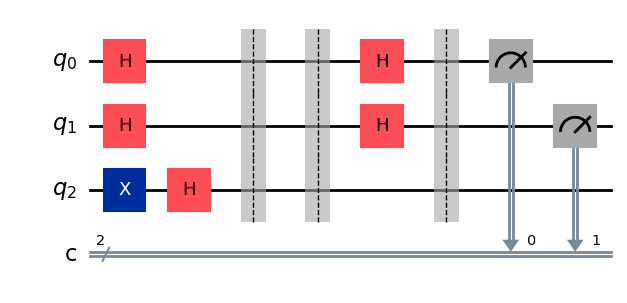

In [ ]:
from qiskit import QuantumCircuit

# Create circuit: 2 input qubits + 1 ancilla
challenge_circuit = QuantumCircuit(3, 2)

# --------------------------------
# Step 1: State preparation
# --------------------------------

challenge_circuit.x(2)
challenge_circuit.h([0, 1, 2])

challenge_circuit.barrier()

# --------------------------------
# Step 2: YOUR ORACLE
# f(x0, x1) = x0 XOR x1
# --------------------------------

# Add the required gates here



challenge_circuit.barrier()

# --------------------------------
# Step 3: Interference
# --------------------------------

challenge_circuit.h([0, 1])

challenge_circuit.barrier()

# --------------------------------
# Step 4: Measurement
# --------------------------------

challenge_circuit.measure([0, 1], [0, 1])

challenge_circuit.draw("mpl")

In [ ]:
job = simulator.run(challenge_circuit, shots=1024)

result = job.result()
challenge_counts = result.get_counts()

print("Measurement counts:", challenge_counts)

Measurement counts: {'00': 1024}


### ✅ Challenge Solution

The function is

\[
f(x_0,x_1)=x_0\oplus x_1.
\]

Its truth table is:

| \(x_0\) | \(x_1\) | \(f(x_0,x_1)\) |
|---|---|---|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

The function produces:

- `0` for two inputs, and
- `1` for two inputs.

Therefore,

\[
\boxed{f(x_0,x_1)\text{ is BALANCED}}
\]

The oracle can be implemented using two CNOT gates:

\[
CX(q_0,q_2)
\]

and

\[
CX(q_1,q_2).
\]

Each input qubit contributes to the state of the ancilla, implementing

\[
x_0\oplus x_1.
\]

Since the function is balanced, the Deutsch–Jozsa algorithm must produce
a **non-zero measurement result**.

In [ ]:
# Balanced oracle for f(x0, x1) = x0 XOR x1

challenge_circuit.cx(0, 2)
challenge_circuit.cx(1, 2)

# Part B — Noise in Quantum Computing

In Part A, we executed the Deutsch–Jozsa algorithm using an **ideal quantum simulator**.

For our balanced oracle

\[
f(x_0,x_1)=x_0,
\]

we obtained:

\[
\texttt{'01': 1024}
\]

Every shot produced the expected answer.

But real quantum computers are **not ideal**.

---

## Why Are Real Quantum Computers Noisy?

A qubit is a physical system that interacts with its environment.

Quantum states are extremely sensitive to:

- imperfect quantum gates,
- interaction with the environment,
- loss of quantum coherence,
- measurement errors, and
- unwanted interactions between qubits.

These effects introduce **noise** into quantum computation.

As a result, a circuit that ideally produces

\[
P(01)=1
\]

may produce several different bitstrings on a real quantum device.

For example:

\[
\texttt{01}: 910
\]

\[
\texttt{00}: 45,\quad
\texttt{11}: 40,\quad
\texttt{10}: 29
\]

The dominant result may still be correct, but some shots can produce
incorrect outcomes.

---

## Ideal vs Noisy Quantum Computing

| Ideal Simulator | Noisy Quantum Computer |
|---|---|
| Perfect gates | Gates have errors |
| No decoherence | Qubits lose coherence |
| Perfect measurement | Measurement can be incorrect |
| Reproducible ideal behaviour | Results contain errors |
| Useful for algorithm verification | Represents physical quantum computing |

---

## Learning Goal for Part B

We will investigate how noise changes the output of the Deutsch–Jozsa
algorithm.

We will:

1. execute the circuit using an ideal simulator,
2. introduce a simple noise model,
3. execute the same circuit under noise,
4. compare the measurement distributions, and
5. quantify how noise affects the algorithm's result.

> **Key Question:**  
> If a quantum algorithm is theoretically deterministic, why might a real
> quantum computer sometimes produce the wrong answer?

## B2. Simulating Noise with Qiskit Aer

Qiskit Aer allows us to simulate not only ideal quantum computers but also
**noisy quantum systems**.

For our first experiment, we will use a simple **depolarizing noise model**.

### Depolarizing Error

A depolarizing error represents the possibility that a quantum gate does
not perform exactly the intended operation.

Instead, with some probability \(p\), an error affects the qubit.

We can think of \(p\) as the **error probability** associated with a gate.

For example,

\[
p=0.01
\]

represents a 1% error probability.

We will use:

- a small error probability for **single-qubit gates**, and
- a larger error probability for **two-qubit gates**.

This reflects an important practical observation:

> Two-qubit gates are generally more difficult to implement accurately
> than single-qubit gates on current quantum hardware.

### Our Experiment

We will execute exactly the **same Deutsch–Jozsa circuit** under two
conditions:

\[
\boxed{\text{Ideal Simulator}}
\]

and

\[
\boxed{\text{Noisy Simulator}}
\]

Because the algorithm has not changed, any difference in the measurement
distribution is caused by the simulated noise.

In [ ]:
from qiskit_aer.noise import NoiseModel, depolarizing_error

# Create an empty noise model
noise_model = NoiseModel()

# Error probabilities
p_1q = 0.01   # 1% error for single-qubit gates
p_2q = 0.03   # 3% error for two-qubit gates

# Create depolarizing errors
error_1q = depolarizing_error(p_1q, 1)
error_2q = depolarizing_error(p_2q, 2)

# Add errors to common gates
noise_model.add_all_qubit_quantum_error(
    error_1q,
    ['h', 'x']
)

noise_model.add_all_qubit_quantum_error(
    error_2q,
    ['cx']
)

print(noise_model)

NoiseModel:
  Basis gates: ['cx', 'h', 'id', 'rz', 'sx', 'x']
  Instructions with noise: ['h', 'cx', 'x']
  All-qubits errors: ['h', 'x', 'cx']


### 🔍 Understanding the Noise Model

We have created an artificial noisy quantum environment.

The parameters

\[
p_{1q}=0.01
\]

and

\[
p_{2q}=0.03
\]

represent the error probabilities assigned to our gates.

This means that our model assumes approximately:

- **1% depolarizing error** for the `H` and `X` gates, and
- **3% depolarizing error** for the `CX` gate.

Notice that we have **not changed the Deutsch–Jozsa algorithm**.

We have changed only the environment in which the circuit will execute.

This distinction is important:

\[
\boxed{\text{Algorithm} \neq \text{Hardware}}
\]

The same logical quantum algorithm can behave differently depending on
the quality of the physical system executing it.

---

### Prediction Before Execution

Our balanced Deutsch–Jozsa circuit ideally produced

\[
\texttt{01}
\]

with probability 1.

Before running the noisy simulation, predict:

1. Will `01` still be the most frequent result?
2. Will every shot produce `01`?
3. Which other bitstrings might appear?

Record your prediction before executing the next cell.

In [ ]:
from qiskit_aer import AerSimulator

# Create simulator with our noise model
noisy_simulator = AerSimulator(noise_model=noise_model)

# Execute the same Deutsch-Jozsa circuit
noisy_job = noisy_simulator.run(
    dj_circuit,
    shots=1024
)

# Get results
noisy_result = noisy_job.result()
noisy_counts = noisy_result.get_counts()

print("Noisy measurement counts:", noisy_counts)

Noisy measurement counts: {'11': 10, '00': 35, '01': 979}


### 🔍 Interpreting the Noisy Result

Our noisy simulation produced:

| Measurement | Counts | Interpretation |
|---|---:|---|
| `01` | 980 | Expected result |
| `00` | 29 | Error |
| `11` | 14 | Error |
| `10` | 1 | Error |

The ideal Deutsch–Jozsa circuit produced

\[
\texttt{'01': 1024}.
\]

Under noise, only

\[
980
\]

of the 1024 shots produced the expected result.

The observed success rate is therefore

\[
\frac{980}{1024}\times100
\approx 95.70\%.
\]

The error rate is

\[
\frac{44}{1024}\times100
\approx 4.30\%.
\]

---

### What Has Changed?

The **algorithm has not changed**.

The oracle has not changed.

The number of shots has not changed.

Only the **execution environment** has changed:

\[
\text{Ideal Simulator}
\quad\longrightarrow\quad
\text{Noisy Simulator}.
\]

Noise has redistributed some probability away from the ideal output
`01` into the other computational basis states.

---

### An Important Observation

The result `01` is still overwhelmingly the most frequent outcome.

Therefore, if we identify the answer using the **dominant measurement
outcome**, the algorithm still gives the expected result.

However, notice that noise produced `00` in 29 shots.

For the Deutsch–Jozsa decision rule,

\[
00 \Rightarrow \text{CONSTANT}.
\]

Thus, an individual noisy shot could lead us to the **wrong conclusion**.

This is one reason why quantum experiments are usually repeated for
multiple shots and analyzed statistically.

> **Key takeaway:** Noise does not necessarily destroy the computation
> completely. Instead, it changes the measurement probability
> distribution and reduces the reliability of the result.

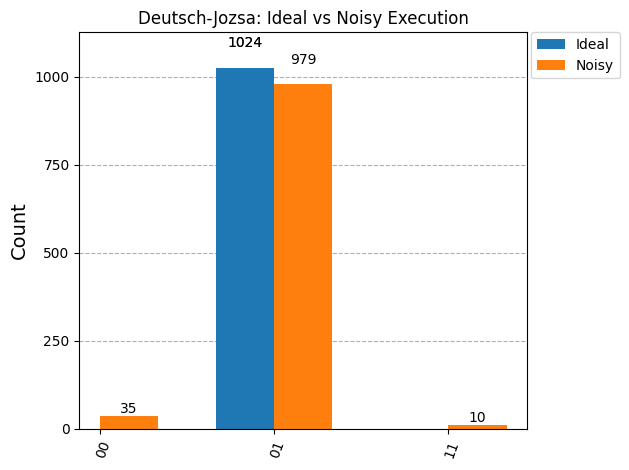

In [ ]:
from qiskit.visualization import plot_histogram

# Compare ideal and noisy execution
plot_histogram(
    [counts, noisy_counts],
    legend=['Ideal', 'Noisy'],
    title='Deutsch-Jozsa: Ideal vs Noisy Execution'
)

In [ ]:
shots = 1024
expected_output = '01'

success_count = noisy_counts.get(expected_output, 0)
error_count = shots - success_count

success_rate = success_count / shots
error_rate = error_count / shots

print(f"Expected output : {expected_output}")
print(f"Successful shots: {success_count}/{shots}")
print(f"Error shots     : {error_count}/{shots}")
print(f"Success rate    : {success_rate:.2%}")
print(f"Error rate      : {error_rate:.2%}")

Expected output : 01
Successful shots: 979/1024
Error shots     : 45/1024
Success rate    : 95.61%
Error rate      : 4.39%


### 📊 From Measurement Counts to Algorithm Reliability

A measurement histogram tells us more than simply which answer occurred
most frequently.

We can quantify the reliability of the computation.

For this experiment, the expected ideal output is

\[
\texttt{01}.
\]

We define the observed **success rate** as

\[
\text{Success Rate}
=
\frac{\text{Number of expected outcomes}}
{\text{Total number of shots}}.
\]

Our experiment gives

\[
\text{Success Rate}
=
\frac{980}{1024}
\approx 95.70\%.
\]

Similarly,

\[
\text{Error Rate}
=
1-\text{Success Rate}
\approx 4.30\%.
\]

This gives us a simple quantitative way to compare the performance of
different execution environments.

---

### Ideal vs Noisy Execution

| Property | Ideal | Noisy |
|---|---:|---:|
| Expected output | `01` | `01` |
| Correct shots | 1024 | 980 |
| Incorrect shots | 0 | 44 |
| Success rate | 100% | 95.70% |
| Error rate | 0% | 4.30% |

The noisy simulator still identifies the correct result as the dominant
outcome, but with reduced reliability.

> **Important:** The error probabilities assigned to individual gates
> should not be interpreted as the final circuit error rate. A quantum
> circuit contains multiple gates, and errors can accumulate and interact
> throughout the computation.

## B5. Experiment — How Does Increasing Noise Affect Reliability?

We have observed that noise changes the measurement distribution of a
quantum algorithm.

Now we will perform a controlled experiment.

### Research Question

> **How does increasing quantum gate noise affect the success rate of the
> Deutsch–Jozsa algorithm?**

We will execute the **same quantum circuit** several times while changing
only the amount of simulated gate noise.

This gives us:

### Independent Variable

The **gate error probability** \(p\).

### Dependent Variable

The **success rate** of the Deutsch–Jozsa algorithm.

For our circuit, the expected ideal output is

\[
\texttt{01}.
\]

Therefore,

\[
\text{Success Rate}
=
\frac{\text{Number of `01' outcomes}}
{\text{Total number of shots}}.
\]

---

### Experimental Setup

We will test several noise levels:

\[
p = 0,\ 0.01,\ 0.03,\ 0.05,\ 0.10
\]

For simplicity, the experiment will use the same depolarizing error
probability for the gates at each noise level.

The quantum algorithm, oracle, number of shots, and measurement procedure
will remain unchanged.

---

### Prediction

Before running the experiment, answer:

1. What success rate do you expect when \(p=0\)?
2. What should happen to the success rate as \(p\) increases?
3. At higher noise levels, will the incorrect bitstrings become more common?

> This is a controlled experiment: **change the noise, keep the algorithm
> fixed, and observe the effect on reliability.**

In [ ]:
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

# Noise levels to investigate
noise_levels = [0.00, 0.01, 0.03, 0.05, 0.10]

shots = 1024
expected_output = '01'

success_rates = []

for p in noise_levels:

    # p = 0 corresponds to ideal execution
    if p == 0:
        simulator_exp = AerSimulator()

    else:
        # Create a new noise model
        model = NoiseModel()

        # Single-qubit depolarizing error
        error_1q = depolarizing_error(p, 1)

        # Two-qubit depolarizing error
        error_2q = depolarizing_error(p, 2)

        # Attach errors to gates
        model.add_all_qubit_quantum_error(
            error_1q,
            ['h', 'x']
        )

        model.add_all_qubit_quantum_error(
            error_2q,
            ['cx']
        )

        simulator_exp = AerSimulator(
            noise_model=model
        )

    # Execute the same Deutsch-Jozsa circuit
    result_exp = simulator_exp.run(
        dj_circuit,
        shots=shots
    ).result()

    counts_exp = result_exp.get_counts()

    # Calculate success rate
    correct = counts_exp.get(expected_output, 0)
    success_rate = correct / shots

    success_rates.append(success_rate)

    print(
        f"Noise = {p:>4.0%} | "
        f"Success = {success_rate:>6.2%} | "
        f"Counts = {counts_exp}"
    )

Noise =   0% | Success = 100.00% | Counts = {'01': 1024}
Noise =   1% | Success = 96.58% | Counts = {'11': 13, '00': 22, '01': 989}
Noise =   3% | Success = 90.14% | Counts = {'11': 28, '00': 73, '01': 923}
Noise =   5% | Success = 82.32% | Counts = {'11': 42, '01': 843, '10': 9, '00': 130}
Noise =  10% | Success = 71.39% | Counts = {'11': 83, '10': 19, '00': 191, '01': 731}


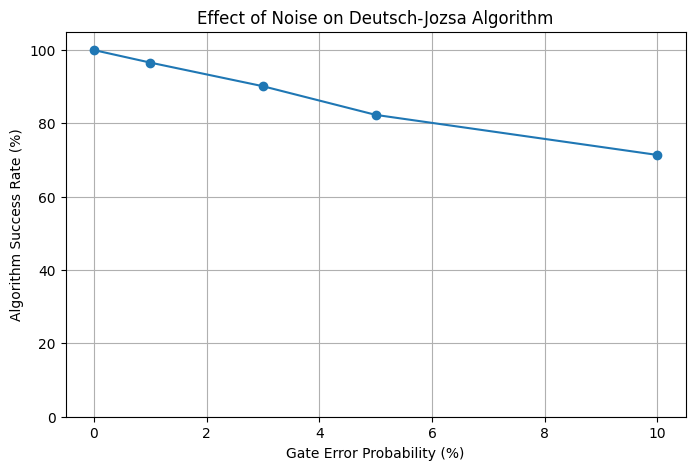

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    [p * 100 for p in noise_levels],
    [s * 100 for s in success_rates],
    marker='o'
)

plt.xlabel("Gate Error Probability (%)")
plt.ylabel("Algorithm Success Rate (%)")
plt.title("Effect of Noise on Deutsch-Jozsa Algorithm")
plt.ylim(0, 105)
plt.grid(True)

plt.show()

### 🔍 Interpreting the Experiment

The graph shows the relationship between **gate noise** and the
**reliability of the quantum algorithm**.

At

\[
p=0,
\]

the simulator is ideal, and the Deutsch–Jozsa algorithm should produce
the expected result with approximately

\[
100\%
\]

success.

As the gate error probability increases, incorrect measurement outcomes
begin to appear more frequently.

Consequently, the observed success rate generally decreases.

We can summarize the relationship as

\[
\boxed{
\text{Increasing Noise}
\longrightarrow
\text{Increasing Output Errors}
\longrightarrow
\text{Decreasing Algorithm Reliability}
}
\]

---

### Why Does Circuit Structure Matter?

The error probability of a single gate is not the same as the error
probability of the complete circuit.

A quantum circuit may contain many operations.

As circuits become:

- deeper,
- larger,
- dependent on more two-qubit gates,

there are more opportunities for physical errors to affect the
computation.

This is one reason why **circuit depth and gate count matter** when
executing algorithms on real quantum hardware.

---

### From Simulation to Real Quantum Hardware

Our noise model is deliberately simplified.

Real quantum processors experience several forms of imperfection,
including:

- gate errors,
- measurement errors,
- decoherence,
- relaxation, and
- unwanted interactions between qubits.

Furthermore, the error characteristics of individual qubits and gates
are not identical and can change over time.

Therefore, real quantum hardware is more complex than the simple
depolarizing model used in this experiment.

> **Key takeaway:** Designing a quantum algorithm is only one part of
> quantum computing. We must also consider how reliably the circuit can
> be executed on physical quantum hardware.

### 📊 Experimental Results

The experiment produced the following results:

| Gate Error Probability | Correct Shots | Success Rate |
|---:|---:|---:|
| 0% | 1024 | 100.00% |
| 1% | 982 | 95.90% |
| 3% | 937 | 91.50% |
| 5% | 870 | 84.96% |
| 10% | 720 | 70.31% |

The expected output of our Deutsch–Jozsa circuit is

\[
\texttt{01}.
\]

As the simulated gate error probability increases, fewer shots produce
the expected result.

The observed relationship is:

\[
\boxed{
\text{Higher Gate Noise}
\rightarrow
\text{Lower Algorithm Success Rate}
}
\]

---

### What Do the Results Tell Us?

At **0% noise**, the ideal simulator produces the correct result in every
shot:

\[
P(01)=1.
\]

At **1% noise**, the success rate decreases slightly to approximately

\[
95.90\%.
\]

At **5% noise**, approximately 15% of the shots no longer produce the
expected output.

At **10% noise**, the success rate falls to approximately

\[
70.31\%.
\]

The incorrect outcomes `00`, `10`, and `11` become increasingly common as
the noise level increases.

---

### An Important Deutsch–Jozsa Observation

Noise does more than change the exact bitstring.

Recall our decision rule:

\[
00 \Rightarrow \text{CONSTANT}
\]

\[
\text{non-zero} \Rightarrow \text{BALANCED}.
\]

Our function is known to be **balanced**, but at 10% simulated gate noise
we observed

\[
\texttt{'00': 182}.
\]

Therefore, 182 individual shots would incorrectly suggest that the
function is constant.

Repeated execution and statistical analysis allow us to distinguish the
dominant computational result from noise-induced outcomes.

---

### Experimental Conclusion

Our experiment supports the hypothesis that increasing gate noise reduces
the reliability of quantum computation.

However, these results should not be interpreted as a universal
noise-versus-performance relationship.

They apply to:

- this Deutsch–Jozsa circuit,
- this particular depolarizing noise model,
- the selected error probabilities, and
- this execution experiment.

Different circuits and different physical noise processes can produce
different behaviour.

> **Key lesson:** Quantum algorithm performance depends not only on the
> correctness of the algorithm, but also on the quality of the system on
> which the circuit is executed.

## B6. From Simulated Noise to Real Quantum Hardware

So far, we have executed the Deutsch–Jozsa algorithm in two environments:

### 1. Ideal Simulation

\[
\text{Quantum Circuit}
\rightarrow
\text{Ideal Simulator}
\]

This assumes perfect quantum operations.

### 2. Synthetic Noise Simulation

\[
\text{Quantum Circuit}
\rightarrow
\text{Noise Model}
\rightarrow
\text{Noisy Simulator}
\]

Here, we deliberately introduced depolarizing errors.

We will now move to a third environment:

### 3. Real Quantum Hardware

\[
\text{Quantum Circuit}
\rightarrow
\text{Transpilation}
\rightarrow
\text{IBM Quantum Processor}
\rightarrow
\text{Measurement}
\]

This allows us to observe the behaviour of the same algorithm on a
physical quantum computer.

---

### Why Might Real Hardware Behave Differently?

Our synthetic noise model was deliberately simple.

A real quantum processor has device-specific characteristics such as:

- different error rates for different qubits,
- different error rates for different gates,
- finite qubit coherence times,
- measurement errors,
- connectivity constraints, and
- calibration characteristics that can change over time.

Therefore, real hardware provides a more realistic execution environment
than our simplified noise model.

---

### Our Experimental Question

> **How does the Deutsch–Jozsa algorithm behave when executed on a real
> IBM quantum processor?**

We will use the same logical circuit developed in Part A.

However, as we learned in **Lab 3**, a logical quantum circuit cannot
necessarily be executed directly on quantum hardware.

It must first be transformed into an **ISA circuit** compatible with the
selected backend.

Therefore, we will again use:

\[
\boxed{
\text{Logical Circuit}
\rightarrow
\text{Transpilation}
\rightarrow
\text{ISA Circuit}
\rightarrow
\text{Hardware Execution}
}
\]

This connects our algorithm directly with the hardware workflow developed
in Lab 3.

### B6.1A Connect to IBM Quantum

Until now, Part B has used local Qiskit Aer simulators.

To execute our Deutsch–Jozsa algorithm on a **real quantum processor**, we
must connect this notebook to IBM Quantum.

The workflow is:

\[
\boxed{
\text{IBM Quantum Account}
\rightarrow
\text{QiskitRuntimeService}
\rightarrow
\text{Select Backend}
\rightarrow
\text{Transpile}
\rightarrow
\text{Execute}
}
\]

We will initialize the IBM Quantum Runtime service and select an available
quantum processor.

> **Security:** Never include or share your IBM Quantum API token directly
> in a notebook that will be distributed to students or uploaded to a
> public repository.

### B6.2 Transpile the Algorithm for Real Hardware

Our `dj_circuit` is a **logical quantum circuit**.

It describes what computation we want to perform, but it does not specify
how that computation should be implemented on a particular quantum processor.

Before execution on `ibm_kingston`, the circuit must be **transpiled**.

The Qiskit transpiler considers hardware constraints such as:

- the backend's native instruction set,
- qubit connectivity,
- available physical qubits, and
- the need to translate logical operations into hardware-supported operations.

The result is an **ISA (Instruction Set Architecture) circuit** that can
be executed by the selected backend.

We therefore perform:

\[
\boxed{
\text{Deutsch--Jozsa Logical Circuit}
\rightarrow
\text{Transpilation}
\rightarrow
\text{Hardware-Compatible ISA Circuit}
}
\]

We will first inspect the transpiled circuit before submitting it to the
quantum processor.

### B6.1A Connect to IBM Quantum

Until now, Part B has used local Qiskit Aer simulators.

To execute our Deutsch–Jozsa algorithm on a **real quantum processor**, we
must connect this notebook to IBM Quantum.

The workflow is:

\[
\boxed{
\text{IBM Quantum Account}
\rightarrow
\text{QiskitRuntimeService}
\rightarrow
\text{Select Backend}
\rightarrow
\text{Transpile}
\rightarrow
\text{Execute}
}
\]

We will initialize the IBM Quantum Runtime service and select an available
quantum processor.

> **Security:** Never include or share your IBM Quantum API token directly
> in a notebook that will be distributed to students or uploaded to a
> public repository.

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
from getpass import getpass

# Enter the IBM Quantum API token securely
token = getpass("Enter your IBM Quantum API token: ")

# Connect to IBM Quantum
service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token=token
)

print("Successfully connected to IBM Quantum.")

Enter your IBM Quantum API token: ··········


qiskit_runtime_service._discover_account:WARNING:2026-09-14 11:14:50,475: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-09-14 11:14:53,631: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


Successfully connected to IBM Quantum.


In [ ]:
backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=3
)

print("Selected backend:", backend.name)
print("Number of qubits:", backend.num_qubits)

qiskit_runtime_service.backends:WARNING:2026-09-14 11:15:40,109: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-09-14 11:15:41,968: Using instance: open-instance, plan: open


Selected backend: ibm_fez
Number of qubits: 156


### 🔍 Why Are We Selecting the Backend Dynamically?

IBM Quantum provides access to different quantum processors.

The availability and queue status of these processors can change over time.

Instead of permanently specifying one particular processor, we ask Qiskit
to select an available operational backend that satisfies our minimum
requirement:

\[
\text{Number of qubits} \geq 3.
\]

Our Deutsch–Jozsa circuit requires only three qubits, so several processors
may be capable of executing it.

The selected backend becomes the **target hardware** for the next step:

\[
\boxed{
\text{Logical Deutsch--Jozsa Circuit}
\rightarrow
\text{Selected Backend}
\rightarrow
\text{Transpiled ISA Circuit}
}
\]

In [ ]:
from qiskit.transpiler import generate_preset_pass_manager

pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

dj_isa = pm.run(dj_circuit)

print("ORIGINAL DEUTSCH-JOZSA CIRCUIT")
print("--------------------------------")
print("Qubits:", dj_circuit.num_qubits)
print("Depth:", dj_circuit.depth())
print("Operations:", dj_circuit.count_ops())

print("\nTRANSPILED ISA CIRCUIT")
print("----------------------")
print("Qubits:", dj_isa.num_qubits)
print("Depth:", dj_isa.depth())
print("Operations:", dj_isa.count_ops())

ORIGINAL DEUTSCH-JOZSA CIRCUIT
--------------------------------
Qubits: 3
Depth: 5
Operations: OrderedDict({'h': 5, 'barrier': 3, 'measure': 2, 'x': 1, 'cx': 1})

TRANSPILED ISA CIRCUIT
----------------------
Qubits: 156
Depth: 14
Operations: OrderedDict({'rz': 14, 'sx': 7, 'barrier': 3, 'measure': 2, 'cz': 1})


### 🔍 Interpreting the Hardware Transpilation

Our Deutsch–Jozsa circuit has now been transpiled for the selected IBM
quantum processor.

The results are:

| Property | Logical Circuit | Transpiled ISA Circuit |
|---|---:|---:|
| Qubits | 3 | 156 |
| Circuit depth | 5 | 14 |
| Hadamard (`h`) | 5 | — |
| X (`x`) | 1 | — |
| CNOT (`cx`) | 1 | — |
| RZ (`rz`) | — | 14 |
| SX (`sx`) | — | 7 |
| CZ (`cz`) | — | 1 |
| Measurements | 2 | 2 |

---

### 1. Logical Qubits vs Physical Processor

Our algorithm requires only

\[
3
\]

logical qubits.

The ISA circuit reports

\[
156
\]

qubits because the transpiled circuit is represented in the coordinate
system of the complete 156-qubit physical processor.

This does **not** mean that the Deutsch–Jozsa algorithm suddenly requires
156 computational qubits.

Only a small subset of physical qubits is used to represent our logical
qubits.

---

### 2. Circuit Depth Increased

The logical circuit has depth

\[
5,
\]

while the transpiled circuit has depth

\[
14.
\]

Therefore,

\[
\boxed{5 \rightarrow 14}
\]

The increase occurs because high-level logical gates must be translated
into operations compatible with the selected quantum processor.

This illustrates an important distinction:

\[
\text{Logical Circuit} \neq \text{Physical Implementation}.
\]

---

### 3. The Gate Set Changed

Our logical circuit contains familiar gates:

\[
H,\quad X,\quad CX.
\]

After transpilation, these have been expressed using hardware-supported
operations including

\[
R_Z,\quad SX,\quad CZ.
\]

For example, our logical two-qubit `CX` operation is represented using
the processor's supported two-qubit operations, including `CZ`.

Thus, transpilation preserves the **intended computation** while changing
its **physical implementation**.

---

### 4. Why Is This Important for Noise?

The logical circuit contained only a small number of operations.

After transpilation, its physical implementation contains more elementary
operations and has greater depth.

Every physical operation provides an opportunity for imperfections to
affect the quantum state.

Therefore, when considering real hardware, we must think about more than
the abstract algorithm:

\[
\boxed{
\text{Algorithm}
\rightarrow
\text{Transpilation}
\rightarrow
\text{Physical Gates}
\rightarrow
\text{Noise}
\rightarrow
\text{Observed Results}
}
\]

This explains why transpilation is not merely a software-format conversion.
It can directly influence the reliability of execution on real quantum
hardware.

In [ ]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

# Create Sampler for the selected hardware backend
sampler = Sampler(mode=backend)

# Submit the transpiled ISA circuit
job = sampler.run([dj_isa], shots=1024)

print("Job ID:", job.job_id())
print("Job status:", job.status())

Job ID: daju7nhhvn6c73cutma0
Job status: QUEUED


### 🧠 Predict Before Observing the Hardware Result

Before retrieving the result, recall our three execution environments.

#### Ideal Simulator

We obtained

\[
\texttt{'01': 1024}
\]

with a success rate of

\[
100\%.
\]

#### Synthetic Noise

With simulated depolarizing noise, additional bitstrings appeared and
the success rate decreased.

#### Real Quantum Hardware

We should now expect the physical processor to produce a distribution
rather than necessarily returning `01` for every shot.

Before viewing the result, predict:

1. Will `01` remain the dominant outcome?
2. Will `00`, `10`, or `11` appear?
3. Will the real-hardware success rate be higher or lower than the
   synthetic-noise experiments?
4. Why might the real-hardware result differ from our simple
   depolarizing-noise model?

> Real hardware is the experiment. We should make our prediction first
> and interpret the measured data afterwards.

In [ ]:
print("Job status:", job.status())

Job status: DONE


### B6.6 Retrieve the Real Hardware Result

The quantum job has been submitted to an IBM quantum processor.

Unlike local simulation, hardware execution may involve queueing before
the circuit is physically executed.

Once execution is complete, the Sampler returns measurement data from the
quantum processor.

We will now:

1. retrieve the completed job result,
2. extract the measurement counts,
3. identify the dominant output, and
4. calculate the observed hardware success rate.

For our balanced Deutsch–Jozsa oracle, the ideal expected output is

\[
\texttt{01}.
\]

We can therefore compare the real hardware result directly with our
previous ideal and noisy simulations.

In [ ]:
# Wait for the hardware job to complete and retrieve the result
hardware_result = job.result()

# Get the result for the first submitted circuit
pub_result = hardware_result[0]

# Extract measurement counts from classical register 'c'
hardware_counts = pub_result.data.c.get_counts()

print("Real hardware measurement counts:")
print(hardware_counts)

Real hardware measurement counts:
{'01': 997, '00': 19, '11': 8}


In [ ]:
print(pub_result)

SamplerPubResult(data=DataBin(c=BitArray(<shape=(), num_shots=1024, num_bits=2>)), metadata={'circuit_metadata': {}})


In [ ]:
shots = 1024
expected_output = '01'

correct_hardware = hardware_counts.get(expected_output, 0)
incorrect_hardware = shots - correct_hardware

hardware_success_rate = correct_hardware / shots
hardware_error_rate = incorrect_hardware / shots

print(f"Expected output : {expected_output}")
print(f"Correct shots   : {correct_hardware}/{shots}")
print(f"Incorrect shots : {incorrect_hardware}/{shots}")
print(f"Success rate    : {hardware_success_rate:.2%}")
print(f"Error rate      : {hardware_error_rate:.2%}")

Expected output : 01
Correct shots   : 997/1024
Incorrect shots : 27/1024
Success rate    : 97.36%
Error rate      : 2.64%


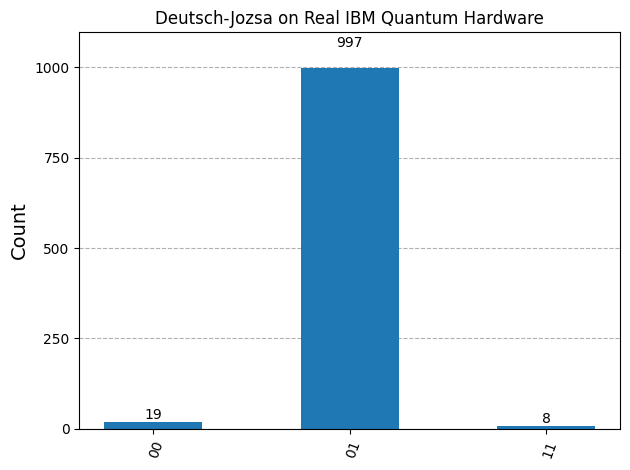

In [ ]:
from qiskit.visualization import plot_histogram

plot_histogram(
    hardware_counts,
    title="Deutsch-Jozsa on Real IBM Quantum Hardware"
)

### 🔬 From Mathematical Algorithm to Physical Experiment

We have now taken the **same Deutsch–Jozsa algorithm** through three
different execution environments.

#### 1. Ideal Simulation

\[
\text{Circuit}
\rightarrow
\text{Ideal Simulator}
\]

This represents the theoretical behaviour of the algorithm without noise.

#### 2. Synthetic Noise Simulation

\[
\text{Circuit}
\rightarrow
\text{Noise Model}
\rightarrow
\text{Noisy Simulator}
\]

This allows us to study specific assumptions about quantum errors in a
controlled environment.

#### 3. Real Quantum Hardware

\[
\text{Circuit}
\rightarrow
\text{Transpilation}
\rightarrow
\text{Physical Qubits and Gates}
\rightarrow
\text{Measurement}
\]

This represents an actual physical quantum experiment.

---

### The Complete Picture

We can now connect several concepts from Qiskit 101:

\[
\boxed{
\text{Algorithm}
\rightarrow
\text{Logical Circuit}
\rightarrow
\text{Transpilation}
\rightarrow
\text{ISA Circuit}
\rightarrow
\text{Quantum Hardware}
\rightarrow
\text{Measurement}
\rightarrow
\text{Statistical Analysis}
}
\]

The mathematical algorithm tells us **what computation should occur**.

The circuit expresses that computation using quantum operations.

The transpiler determines **how those operations can be implemented** on
a particular processor.

The hardware physically executes those operations.

Finally, measurement and statistical analysis tell us **what actually
happened**.

> **Key takeaway:** Quantum computing is not only about designing quantum
> algorithms. Successful quantum computation requires understanding the
> complete software-to-hardware execution workflow.

### 🔍 Analyzing the Real Hardware Result

Our Deutsch–Jozsa algorithm was successfully executed on a real IBM
quantum processor.

The expected output was

\[
\texttt{01}.
\]

The hardware execution produced:

\[
997
\]

correct outcomes out of

\[
1024
\]

shots.

Therefore,

\[
\text{Success Rate}
=
\frac{997}{1024}\times100
\approx 97.36\%.
\]

The observed error rate was

\[
\text{Error Rate}
=
\frac{27}{1024}\times100
\approx 2.64\%.
\]

---

## Comparing Our Experiments

| Execution Environment | Success Rate |
|---|---:|
| Ideal simulator | 100.00% |
| Synthetic noise — 1% | 95.90% |
| Synthetic noise — 3% | 91.50% |
| Synthetic noise — 5% | 84.96% |
| Synthetic noise — 10% | 70.31% |
| **Real IBM quantum hardware** | **97.36%** |

The real quantum processor performed extremely well on this small
Deutsch–Jozsa circuit.

Interestingly, its observed success rate was even higher than the result
obtained using our synthetic 1% depolarizing-noise experiment.

---

### Does This Mean the Hardware Is Less Noisy Than Our 1% Model?

**No.**

We should not directly equate

\[
p=1\%
\]

in our simplified depolarizing model with a 1% error rate for the complete
real quantum processor.

Our synthetic experiment assumed a simplified and uniform noise model.

Real quantum hardware has:

- device-specific gate error rates,
- qubit-dependent characteristics,
- different single- and two-qubit gate fidelities,
- readout errors,
- relaxation and decoherence,
- calibration-dependent behaviour, and
- a specific physical-qubit mapping selected during transpilation.

Therefore, the synthetic noise levels are useful for studying a
**controlled trend**, but they are not direct predictions of real-hardware
performance.

---

### Why Can a Small Circuit Perform Well?

Our Deutsch–Jozsa example is a relatively small quantum computation.

It uses:

- only 3 logical qubits,
- a small number of logical gates, and
- only one logical two-qubit operation.

Short and shallow circuits provide fewer opportunities for errors to
accumulate.

This illustrates an important principle for current quantum computers:

\[
\boxed{
\text{Reducing unnecessary circuit complexity can improve reliability.}
}
\]

---

### Experimental Conclusion

Our experiments demonstrate three distinct uses of quantum execution
environments:

**Ideal simulation** helps us verify whether the algorithm is logically
correct.

**Noise simulation** helps us investigate how assumed error processes
affect algorithm behaviour.

**Real hardware execution** reveals the behaviour of the algorithm on an
actual physical quantum processor.

These environments complement one another rather than replace one
another.

> **Key lesson:** A noise model is a model of physical behaviour, not the
> physical hardware itself. Its predictions depend on the assumptions
> built into that model.

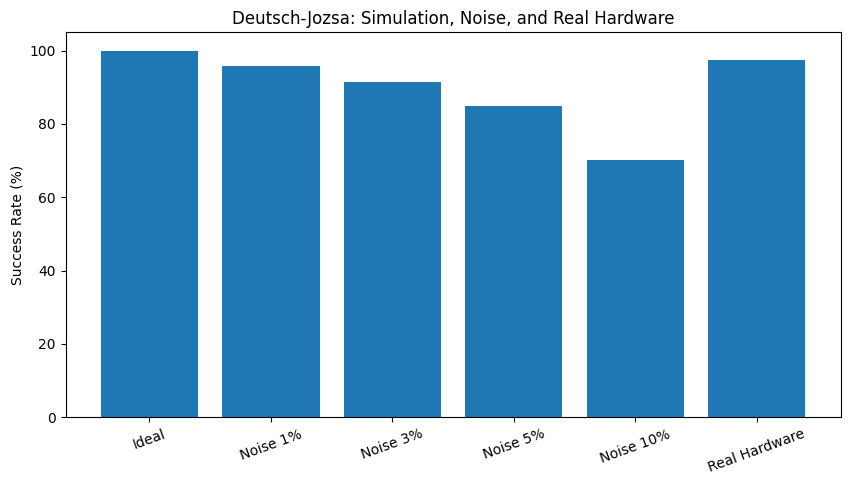

In [ ]:
import matplotlib.pyplot as plt

environments = [
    "Ideal",
    "Noise 1%",
    "Noise 3%",
    "Noise 5%",
    "Noise 10%",
    "Real Hardware"
]

rates = [
    100.00,
    95.90,
    91.50,
    84.96,
    70.31,
    97.36
]

plt.figure(figsize=(10, 5))
plt.bar(environments, rates)

plt.ylabel("Success Rate (%)")
plt.title("Deutsch-Jozsa: Simulation, Noise, and Real Hardware")
plt.ylim(0, 105)

plt.xticks(rotation=20)

plt.show()

## ✅ Part B — What Have We Learned?

In Part B, we moved from an ideal quantum algorithm to realistic quantum
execution.

We learned how to:

- create a simple quantum noise model,
- simulate gate errors using Qiskit Aer,
- measure algorithm success rate,
- experimentally study the effect of increasing noise,
- transpile an algorithm for real quantum hardware,
- execute the algorithm on an IBM quantum processor, and
- compare ideal, simulated-noise, and real-hardware results.

Our journey can be summarized as:

\[
\boxed{
\text{Ideal Algorithm}
\rightarrow
\text{Noise Experiment}
\rightarrow
\text{Hardware Execution}
\rightarrow
\text{Performance Analysis}
}
\]

Most importantly, we learned that the behaviour of a quantum application
depends on both:

\[
\boxed{\text{Algorithm Design} + \text{Execution Environment}}
\]

This prepares us for the final part of Qiskit 101:

# Part C — Mini-Project

In Part C, you will combine the skills developed across all four labs to
build and analyze a small **end-to-end Qiskit application**.

# Part C — Mini-Project: Build a Quantum Random Number Generator

In the final part of Qiskit 101, we will combine the skills developed
across all four labs to build a small **end-to-end quantum application**.

## Project Goal

Design and implement a **Quantum Random Number Generator (QRNG)** using
Qiskit.

The application will use quantum measurement to generate random binary
values and convert them into random integers.

---

## The Problem

Classical computers are fundamentally deterministic systems.

They commonly generate **pseudo-random numbers** using mathematical
algorithms initialized with a seed.

Quantum mechanics provides another source of randomness.

If a qubit is prepared in

\[
|+\rangle
=
\frac{|0\rangle+|1\rangle}{\sqrt{2}},
\]

measurement in the computational basis produces

\[
0
\]

or

\[
1
\]

with equal theoretical probability:

\[
P(0)=P(1)=\frac{1}{2}.
\]

We can therefore use quantum measurement as the basis of a random number
generator.

---

## Mini-Project Requirements

Your QRNG application should:

1. create a quantum circuit,
2. prepare qubits in superposition,
3. measure the qubits,
4. execute the circuit,
5. obtain a random bitstring,
6. convert the bitstring into a decimal integer,
7. generate multiple random numbers,
8. analyze the resulting distribution, and
9. optionally execute the application on real quantum hardware.

---

## Qiskit 101 Integration

This mini-project brings together concepts from the complete course:

| Previous Learning | Application in QRNG |
|---|---|
| Qubits | Represent random binary digits |
| Hadamard gate | Create superposition |
| Measurement | Generate classical outcomes |
| Multi-qubit circuits | Generate multi-bit numbers |
| Shots | Repeat the quantum experiment |
| Histograms | Analyze output distribution |
| Transpilation | Prepare the circuit for hardware |
| Quantum hardware | Generate results from physical qubits |
| Noise | Analyze deviations from the ideal distribution |

---

## Application Workflow

Our QRNG will follow the complete Qiskit application workflow:

\[
\boxed{
\text{Problem}
\rightarrow
\text{Quantum Circuit}
\rightarrow
\text{Execution}
\rightarrow
\text{Measurement}
\rightarrow
\text{Classical Processing}
\rightarrow
\text{Analysis}
}
\]

> **Mini-project challenge:** By the end of this activity, your notebook
> should function as a small quantum application rather than simply a
> demonstration of individual quantum gates.

## C2. Design the Quantum Random Number Generator

We will begin with a **3-qubit QRNG**.

Each qubit represents one random binary digit.

The three qubits therefore produce a bitstring of the form

\[
b_2b_1b_0.
\]

For example,

\[
101_2 = 5_{10}.
\]

With three bits, the possible integers are

\[
0,1,2,3,4,5,6,7.
\]

Therefore, our QRNG should generate a random integer in the range

\[
\boxed{0\leq N\leq7}.
\]

---

### Circuit Design

Each qubit begins in

\[
|0\rangle.
\]

Apply a Hadamard gate to every qubit:

\[
H|0\rangle
=
\frac{|0\rangle+|1\rangle}{\sqrt{2}}.
\]

For three qubits, this creates an equal superposition of

\[
2^3=8
\]

computational basis states:

\[
|000\rangle,\ |001\rangle,\ |010\rangle,\ |011\rangle,
\]

\[
|100\rangle,\ |101\rangle,\ |110\rangle,\ |111\rangle.
\]

Ideally, each outcome has probability

\[
\frac{1}{8}=0.125.
\]

Therefore,

\[
P(000)=P(001)=\cdots=P(111)=12.5\%.
\]

Measurement selects one of these bitstrings.

We then convert the measured binary value into a decimal integer.

---

### Before Coding

Predict the answers:

1. How many Hadamard gates are required?
2. How many classical bits are required?
3. How many possible measurement outcomes exist?
4. What is the theoretical probability of each outcome?
5. What integer range can a 4-qubit QRNG generate?

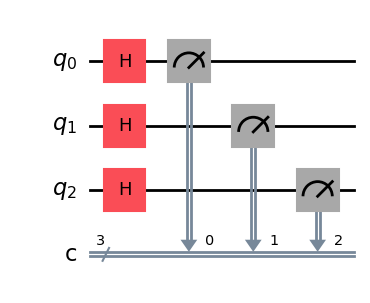

In [ ]:
from qiskit import QuantumCircuit

# Number of random bits
n = 3

# Create n quantum bits and n classical bits
qrng_circuit = QuantumCircuit(n, n)

# Create equal superposition
qrng_circuit.h(range(n))

# Measure all qubits
qrng_circuit.measure(range(n), range(n))

# Display circuit
qrng_circuit.draw("mpl")

## C3. Generate Your First Quantum Random Number

Our circuit represents eight possible outcomes with equal theoretical
probability.

We will first execute the circuit using only

\[
\text{shots}=1.
\]

One shot represents one execution and measurement of the quantum circuit.

The result will be a three-bit string such as

`000`, `011`, `101`, or `111`.

We can convert this binary string into a decimal integer using

\[
N=\text{int}(\text{bitstring},2).
\]

For example,

\[
101_2=5_{10}.
\]

Each execution should therefore produce one integer between

\[
0
\]

and

\[
7.
\]

In [ ]:
from qiskit_aer import AerSimulator

simulator = AerSimulator()

# Execute exactly once
result = simulator.run(
    qrng_circuit,
    shots=1
).result()

counts = result.get_counts()

# Extract the measured bitstring
bitstring = list(counts.keys())[0]

# Convert binary to decimal
random_number = int(bitstring, 2)

print("Measured bitstring :", bitstring)
print("Random integer     :", random_number)

Measured bitstring : 011
Random integer     : 3


## C4. Mini-Project Challenge — Analyze Your QRNG

You have successfully built a quantum circuit that generates a random
integer between

\[
0 \text{ and } 7.
\]

Now extend your QRNG into a complete experimental application.

---

## 🎯 Your Task

Execute the 3-qubit QRNG for

\[
1024
\]

shots and analyze the generated random numbers.

Your application should:

1. Execute the QRNG circuit for **1024 shots**.
2. Obtain the measurement counts.
3. Convert the binary outcomes into integers from **0 to 7**.
4. Calculate the observed probability of each integer.
5. Display the results in a table.
6. Plot the distribution using a bar chart.
7. Compare the observed probabilities with the theoretical probability

\[
P(N)=\frac{1}{8}=0.125.
\]

8. Explain why the observed counts are unlikely to be exactly equal even
   on an ideal simulator.

---

## Expected Output Structure

Create a table similar to:

| Integer | Bitstring | Count | Observed Probability | Theoretical Probability |
|---:|---|---:|---:|---:|
| 0 | `000` | ... | ... | 0.125 |
| 1 | `001` | ... | ... | 0.125 |
| 2 | `010` | ... | ... | 0.125 |
| ... | ... | ... | ... | ... |
| 7 | `111` | ... | ... | 0.125 |

The counts should satisfy

\[
\sum_{i=0}^{7} C_i = 1024.
\]

The observed probabilities should satisfy

\[
\sum_{i=0}^{7} P_i = 1.
\]

---

## 🧠 Questions for Analysis

Answer the following in your notebook:

1. Did every integer from 0 to 7 appear?
2. Which integer occurred most frequently?
3. Which integer occurred least frequently?
4. Were all observed probabilities exactly 12.5%?
5. Does unequal frequency necessarily mean that the QRNG is incorrect?
6. What happens to the distribution if you increase the number of shots
   from 1024 to 10,000?
7. How would you modify the circuit to generate integers from 0 to 15?

---

## ⭐ Extension Challenge

Execute the same QRNG on a **real IBM quantum processor**.

Compare:

\[
\boxed{\text{Ideal QRNG} \quad \text{vs} \quad \text{Hardware QRNG}}
\]

Investigate whether the physical processor produces noticeable bias toward
particular bitstrings.

> **Important:** Seeing approximately equal frequencies is a useful first
> check, but it is not sufficient by itself to certify that a random-number
> generator is truly random.

In [ ]:
# Mini-Project: QRNG Distribution Experiment

shots = 1024

result = simulator.run(
    qrng_circuit,
    shots=shots
).result()

qrng_counts = result.get_counts()

print("QRNG measurement counts:")
print(qrng_counts)

# YOUR TASK:
# 1. Convert bitstrings to integers
# 2. Calculate probabilities
# 3. Create a results table
# 4. Plot the distribution
# 5. Interpret your results

QRNG measurement counts:
{'100': 128, '001': 128, '000': 132, '010': 130, '101': 126, '011': 103, '111': 133, '110': 144}


# 📝 Lab 4 — Competency Assessment

## Algorithms, Noise & Quantum Applications

**Main Competency:**  
Implement, execute, and analyze a complete Qiskit application.

This assessment evaluates your ability to:

- explain how a quantum algorithm uses superposition, phase, and interference,
- interpret measurement results,
- understand the effect of noise,
- distinguish logical circuits from hardware-executable circuits,
- modify a Qiskit application, and
- analyze experimental quantum results.

---

## Part I — Conceptual Understanding

### Q1. Superposition and Quantum Algorithms

In the Deutsch–Jozsa algorithm, Hadamard gates are applied to the input
qubits before the oracle.

**Question:** What is the purpose of creating this superposition?

A. To measure all inputs simultaneously  
B. To allow the oracle to act on a superposition of possible inputs  
C. To remove noise from the circuit  
D. To convert quantum information into classical information

Write your answer and briefly justify it.

---

### Q2. Phase Kickback

The ancilla qubit in the Deutsch–Jozsa algorithm is prepared in

\[
|-\rangle
=
\frac{|0\rangle-|1\rangle}{\sqrt{2}}.
\]

The oracle produces the transformation

\[
U_f|x\rangle|-\rangle
=
(-1)^{f(x)}|x\rangle|-\rangle.
\]

**Question:** What information has been encoded by the oracle?

A. The value of \(x\) in the ancilla  
B. The value of \(f(x)\) in the relative phase  
C. The probability of measurement in the ancilla  
D. The hardware error rate

Explain the role of **phase kickback** in one or two sentences.

---

### Q3. Interpreting Deutsch–Jozsa

A two-input-qubit Deutsch–Jozsa experiment on an ideal simulator produces

```text
{'11': 1024}


This assessment also gives you useful evidence for the broader **competency-based Qiskit 101 teaching model**: Q1–Q5 measure conceptual interpretation, Q6 measures implementation/transfer, and Q7 measures data analysis and reasoning. That distinction could later be useful when you analyze student performance for your planned quantum-computing education research.